Currently just one head file

In [3]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel

In [5]:
from pathlib import Path

print("Notebook working directory:")
print(Path.cwd())

project_root = Path.cwd().parent
lsst_zip = project_root / "data" / "LSST_ALERTS.zip"

print(lsst_zip.resolve())

Notebook working directory:
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip


In [6]:
from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile


head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"

with ZipFile(lsst_zip, "r") as archive:
    head_bytes = gzip.decompress(archive.read(head_name))
    phot_bytes = gzip.decompress(archive.read(phot_name))

with fits.open(BytesIO(head_bytes)) as head_hdul:
    head_hdul.info()
    head_data = head_hdul[1].data
    print("\nHEAD columns:")
    print(head_hdul[1].columns.names)
    print("\nNumber of objects:", len(head_data))

with fits.open(BytesIO(phot_bytes)) as phot_hdul:
    phot_hdul.info()
    phot_data = phot_hdul[1].data
    print("\nPHOT columns:")
    print(phot_hdul[1].columns.names)
    print("\nNumber of photometry rows:", len(phot_data))

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      33   (0,)      
  1  Header        1 BinTableHDU    537   51000R x 176C   [40A, 16A, 20A, 1I, 1I, 1D, 1D, 1E, 1I, 1I, 1J, 1J, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1E, 1E, 1E, 1E, 1I, 1I, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   

HEAD columns:
['SNID', 'NAME_IAUC', 'NAME_TRANSIENT', 'FAKE', 'MASK_

### Selection Cuts
- Nights of observation: `nights` > 5
- Duration Cut:
- Curvature cut?
- Explore classification properties from brokers?

In [21]:
import numpy as np
import time

# Convert FITS columns once
all_mjd = np.asarray(phot_data["MJD"], dtype=float)
all_flag = np.asarray(phot_data["PHOTFLAG"])

ptr_min = np.asarray(head_data["PTROBS_MIN"], dtype=int) - 1
ptr_max = np.asarray(head_data["PTROBS_MAX"], dtype=int)

n_objects = len(head_data)

n_valid_obs = np.zeros(n_objects, dtype=int)
n_nights = np.zeros(n_objects, dtype=int)

start_time = time.perf_counter()

#for i, (start, stop) in enumerate(zip(ptr_min, ptr_max)):
for i, (start, stop) in enumerate(zip(ptr_min[:1000], ptr_max[:1000])):
    mjd = all_mjd[start:stop]
    flag = all_flag[start:stop]

    valid = np.isfinite(mjd) & (flag != 64)
    valid_mjd = mjd[valid]

    n_valid_obs[i] = valid.sum()

    if valid_mjd.size:
        n_nights[i] = np.unique(np.floor(valid_mjd).astype(int)).size

elapsed = time.perf_counter() - start_time
print(f"Finished in {elapsed:.2f} seconds")

Finished in 0.11 seconds


In [22]:
mask = (
    (n_valid_obs > 10)
    & (n_nights >= 3)
)

selected_head = head_data[mask]

print("Before:", len(head_data))
print("After:", len(selected_head))

Before: 51000
After: 60


In [23]:
lengths = ptr_max - ptr_min

print("Pointer-derived lengths:", lengths[:10])
print("HEAD NOBS:", np.asarray(head_data["NOBS"])[:10])
print(
    "All lengths match NOBS:",
    np.all(lengths == np.asarray(head_data["NOBS"]))
)

Pointer-derived lengths: [2 2 2 2 2 2 2 2 2 3]
HEAD NOBS: [2 2 2 2 2 2 2 2 2 3]
All lengths match NOBS: True


In [24]:
print(">10 valid observations:", obs_mask.sum())
print("At least 3 nights:", night_mask.sum())
print("At least 3 filters:", filter_mask.sum())

print("Observations + nights:", (obs_mask & night_mask).sum())
print("All three:", (obs_mask & night_mask & filter_mask).sum())

>10 valid observations: 3380
At least 3 nights: 17572
At least 3 filters: 5798
Observations + nights: 3339
All three: 3222


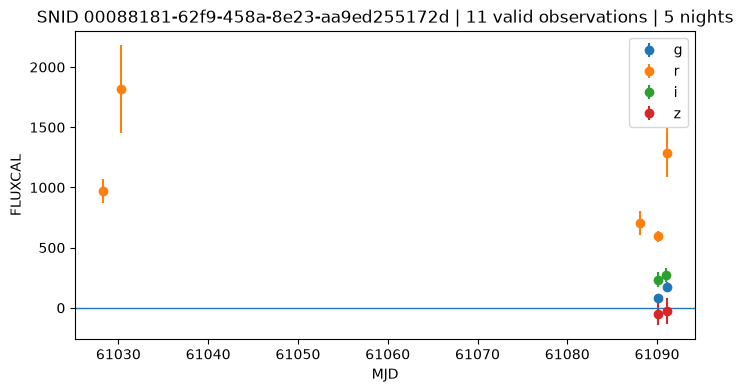

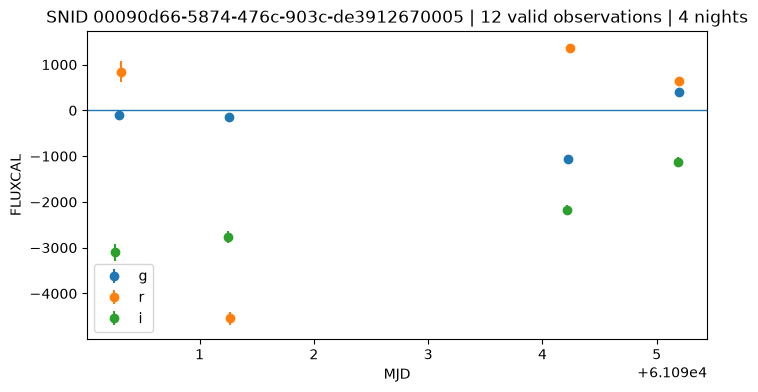

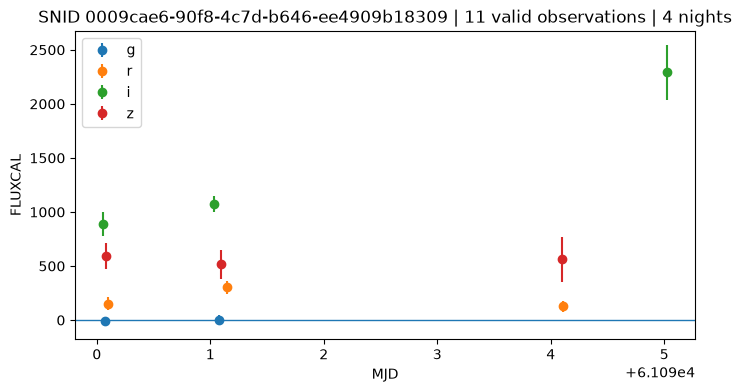

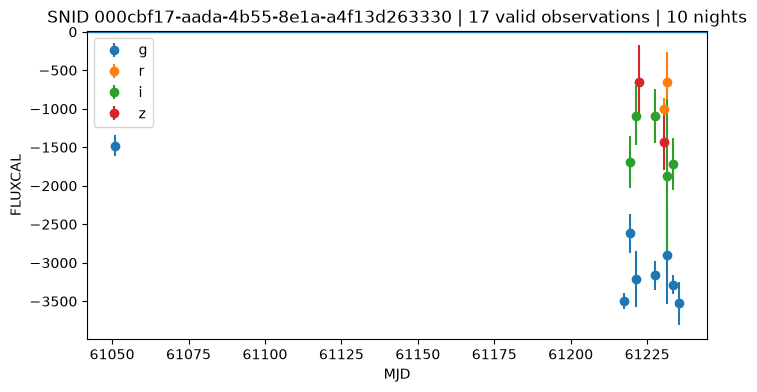

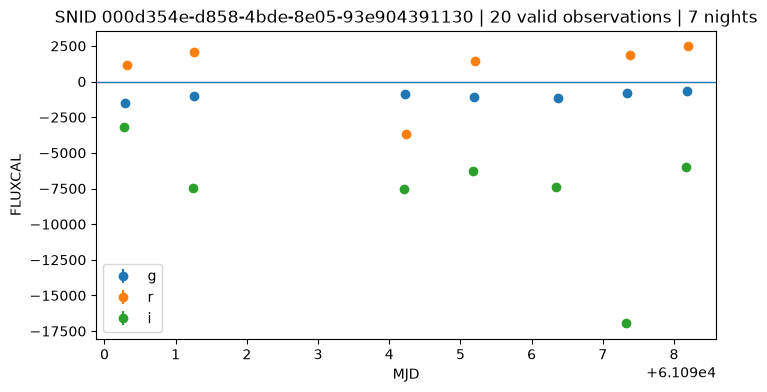

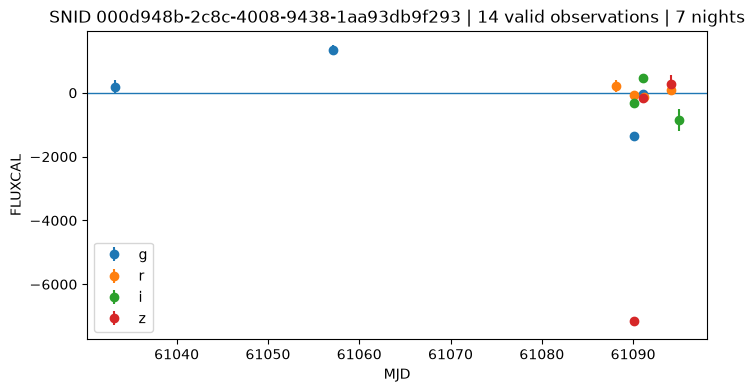

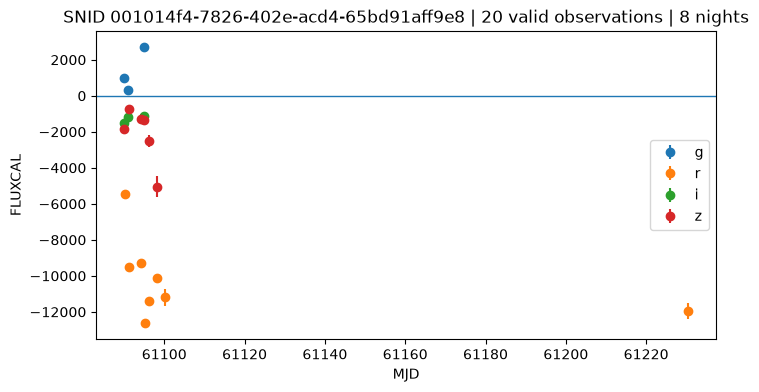

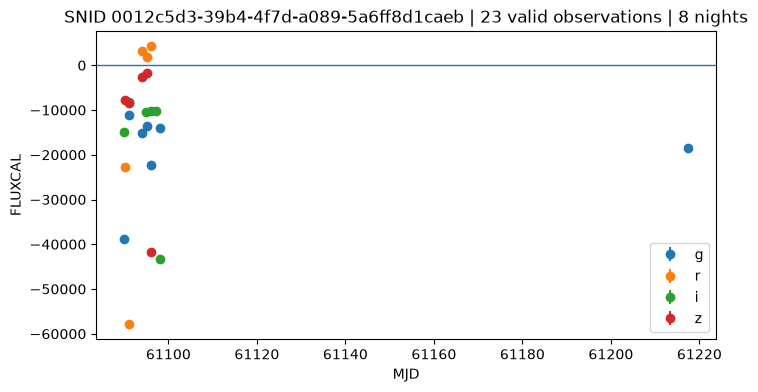

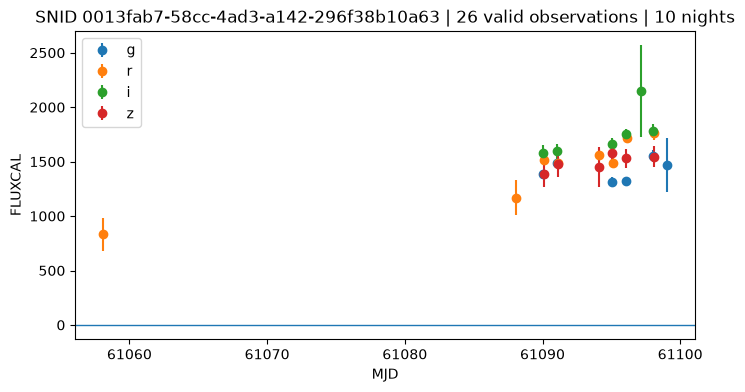

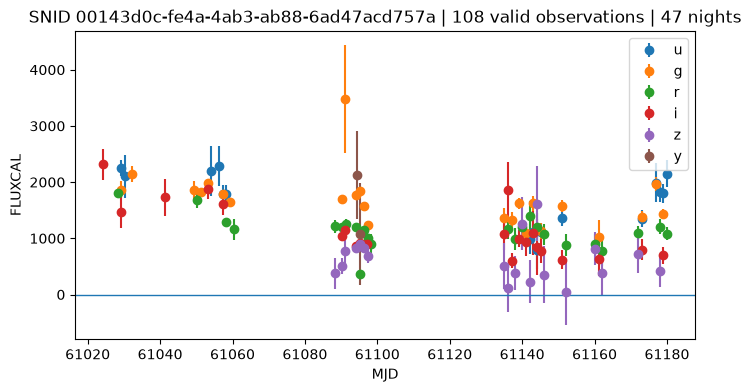

In [16]:
import matplotlib.pyplot as plt
import numpy as np

bands = ["u", "g", "r", "i", "z", "y"]
all_band = np.char.strip(
    np.asarray(phot_data["BAND"]).astype(str)
)

selected_indices = np.where(mask)[0]

for idx in selected_indices[:10]:
    row = head_data[idx]

    start = int(row["PTROBS_MIN"]) - 1
    stop = int(row["PTROBS_MAX"])

    mjd = all_mjd[start:stop]
    flag = all_flag[start:stop]
    flux = np.asarray(phot_data["FLUXCAL"][start:stop], dtype=float)
    fluxerr = np.asarray(phot_data["FLUXCALERR"][start:stop], dtype=float)
    band = np.char.strip(
        np.asarray(phot_data["BAND"][start:stop]).astype(str)
    )

    valid = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & (flag != 64)
    )

    plt.figure(figsize=(8, 4))

    for b in bands:
        band_mask = valid & (band == b)

        if band_mask.any():
            plt.errorbar(
                mjd[band_mask],
                flux[band_mask],
                yerr=fluxerr[band_mask],
                fmt="o",
                label=b,
            )

    plt.axhline(0, linewidth=1)
    plt.xlabel("MJD")
    plt.ylabel("FLUXCAL")
    plt.title(
        f"SNID {row['SNID']} | "
        f"{n_valid_obs[idx]} valid observations | "
        f"{n_nights[idx]} nights"
    )
    plt.legend()
    plt.show()

In [27]:
fluxerr = phot_data["FLUXCALERR"]
print(fluxerr)
print(fluxerr[:20])

[ 404.21  765.39 -777.   ...  274.76  287.61 -777.  ]
[ 404.21  765.39 -777.    732.44  816.4  -777.   1537.3  1592.7  -777.
  235.91  179.36 -777.    415.92  552.98 -777.    235.09  332.67 -777.
 1010.3   992.31]


In [28]:
import numpy as np

fluxerr = np.asarray(phot_data["FLUXCALERR"], dtype=float)

print("Minimum:", np.nanmin(fluxerr))
print("Maximum:", np.nanmax(fluxerr))
print("Median:", np.nanmedian(fluxerr))
print("Finite values:", np.isfinite(fluxerr).sum())
print("Non-positive values:", (fluxerr <= 0).sum())

Minimum: -777.0
Maximum: 244540.0
Median: 270.8399963378906
Finite values: 273660
Non-positive values: 51000


In [29]:
fluxerr = np.asarray(phot_data["FLUXCALERR"], dtype=float)
flux = np.asarray(phot_data["FLUXCAL"], dtype=float)
mjd = np.asarray(phot_data["MJD"], dtype=float)
flag = np.asarray(phot_data["PHOTFLAG"])

valid = (
    np.isfinite(mjd)
    & np.isfinite(flux)
    & np.isfinite(fluxerr)
    & (fluxerr > 0)
    & (flag != 64)
)

In [30]:
snr = np.full(len(flux), np.nan)
snr[valid] = flux[valid] / fluxerr[valid]

In [31]:
clean_fluxerr = fluxerr[valid]

print("Clean minimum:", clean_fluxerr.min())
print("Clean maximum:", clean_fluxerr.max())
print("Clean median:", np.median(clean_fluxerr))
print("Clean rows:", len(clean_fluxerr))

Clean minimum: 12.619000434875488
Clean maximum: 244540.0
Clean median: 346.6400146484375
Clean rows: 214322


In [32]:
snr = flux[valid] / fluxerr[valid]

print("SNR minimum:", np.min(snr))
print("SNR maximum:", np.max(snr))
print("SNR median:", np.median(snr))

print("Positive SNR >= 3:", np.sum(snr >= 3))
print("Positive SNR >= 5:", np.sum(snr >= 5))
print("Negative SNR <= -5:", np.sum(snr <= -5))

SNR minimum: -12644.024395601125
SNR maximum: 2057.171486693684
SNR median: -10.479767770665532
Positive SNR >= 3: 55036
Positive SNR >= 5: 47273
Negative SNR <= -5: 123131


In [33]:
print(
    np.percentile(
        snr,
        [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]
    )
)

[-795.74509004 -164.67192382  -71.76207953  -25.01106769  -10.47976777
    3.33060498   22.17409451   80.21386392  320.11299695]


In [17]:
import numpy as np

bands = ["u", "g", "r", "i", "z", "y"]

all_mjd = np.asarray(phot_data["MJD"], dtype=float)
all_flag = np.asarray(phot_data["PHOTFLAG"])
all_band = np.char.strip(
    np.asarray(phot_data["BAND"]).astype(str)
)

ptr_min = np.asarray(head_data["PTROBS_MIN"], dtype=int) - 1
ptr_max = np.asarray(head_data["PTROBS_MAX"], dtype=int)

n_objects = len(head_data)

n_valid_obs = np.zeros(n_objects, dtype=int)
n_nights = np.zeros(n_objects, dtype=int)
n_filters = np.zeros(n_objects, dtype=int)

for i, (start, stop) in enumerate(zip(ptr_min, ptr_max)):
    mjd = all_mjd[start:stop]
    flag = all_flag[start:stop]
    band = all_band[start:stop]

    valid = (
        np.isfinite(mjd)
        & (flag != 64)
        & np.isin(band, bands)
    )

    valid_mjd = mjd[valid]
    valid_band = band[valid]

    n_valid_obs[i] = valid.sum()
    n_nights[i] = np.unique(np.floor(valid_mjd)).size
    n_filters[i] = np.unique(valid_band).size

In [34]:
all_flux = np.asarray(phot_data["FLUXCAL"], dtype=float)
all_fluxerr = np.asarray(phot_data["FLUXCALERR"], dtype=float)
all_flag = np.asarray(phot_data["PHOTFLAG"])

base_valid = (
    np.isfinite(all_flux)
    & np.isfinite(all_fluxerr)
    & (all_fluxerr > 0)
)

all_snr = np.full(len(all_flux), np.nan)
all_snr[base_valid] = (
    all_flux[base_valid] / all_fluxerr[base_valid]
)

for f in np.unique(all_flag):
    use = base_valid & (all_flag == f)

    print(
        "flag:", f,
        "rows:", use.sum(),
        "median SNR:", np.nanmedian(all_snr[use]),
        "positive >=5:", np.sum(all_snr[use] >= 5),
        "negative <=-5:", np.sum(all_snr[use] <= -5),
    )

flag: 0 rows: 42605 median SNR: 0.31788979643081394 positive >=5: 7159 negative <=-5: 7013
flag: 1 rows: 171714 median SNR: -13.854133950617562 positive >=5: 40114 negative <=-5: 116118
flag: 64 rows: 8338 median SNR: 0.0 positive >=5: 0 negative <=-5: 0
flag: 65 rows: 3 median SNR: 1.0 positive >=5: 0 negative <=-5: 0


In [35]:
for b in bands:
    use = (
        base_valid
        & ((all_flag & 1) != 0)
        & (all_band == b)
    )

    print(
        b,
        "rows:", use.sum(),
        "median flux:", np.median(all_flux[use]),
        "median SNR:", np.median(all_snr[use]),
        "positive fraction:", np.mean(all_flux[use] > 0),
    )


u rows: 1042 median flux: 1936.5 median SNR: 6.609322358364637 positive fraction: 0.6276391554702495
g rows: 22472 median flux: 256.05999755859375 median SNR: 2.4527159249124884 positive fraction: 0.5573157707369171
r rows: 31841 median flux: -1784.300048828125 median SNR: -10.435298845781317 positive fraction: 0.3633679846738482
i rows: 81686 median flux: -6227.25 median SNR: -16.79268500288552 positive fraction: 0.20119726758563278
z rows: 34466 median flux: -9928.900390625 median SNR: -15.701189691857241 positive fraction: 0.2035629315847502
y rows: 210 median flux: 5117.400146484375 median SNR: 5.2273661138240355 positive fraction: 0.6571428571428571


In [36]:
print(
    np.column_stack([
        mjd,
        band,
        flag,
        flux,
        fluxerr,
        flux / fluxerr,
    ])
)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 273660 and the array at index 1 has size 108

In [20]:
obs_mask = n_valid_obs > 10
night_mask = n_nights >= 3
filter_mask = n_filters >= 3

print(">10 valid observations:", obs_mask.sum())
print("At least 3 nights:", night_mask.sum())
print("At least 3 filters:", filter_mask.sum())

print("Observations + nights:", (obs_mask & night_mask).sum())
print("All three:", (obs_mask & night_mask & filter_mask).sum())

>10 valid observations: 3380
At least 3 nights: 17572
At least 3 filters: 5798
Observations + nights: 3339
All three: 3222


In [ ]:
import matplotlib.pyplot as plt

for idx in selected_indices[:10]:
    row = head_data[idx]

    start = ptr_min[idx]
    stop = ptr_max[idx]

    mjd = all_mjd[start:stop]
    flag = all_flag[start:stop]
    band = all_band[start:stop]

    flux = np.asarray(
        phot_data["FLUXCAL"][start:stop],
        dtype=float,
    )
    fluxerr = np.asarray(
        phot_data["FLUXCALERR"][start:stop],
        dtype=float,
    )

    valid = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & (flag != 64)
        & np.isin(band, bands)
    )

    plt.figure(figsize=(8, 4))

    for b in bands:
        band_mask = valid & (band == b)

        if band_mask.any():
            plt.errorbar(
                mjd[band_mask],
                flux[band_mask],
                yerr=fluxerr[band_mask],
                fmt="o",
                label=b,
            )

    plt.axhline(0, linewidth=1)
    plt.xlabel("MJD")
    plt.ylabel("FLUXCAL")
    plt.title(
        f"SNID {row['SNID']} | "
        f"{n_valid_obs[idx]} observations | "
        f"{n_nights[idx]} nights | "
        f"{n_filters[idx]} filters"
    )
    plt.legend()
    plt.show()

In [17]:
# Mask
obvs = head_data["NOBS"]
mask = obvs > 10

selected_head = head_data[mask]

print("Before:", len(head_data))
print("After:", len(selected_head))

Before: 51000
After: 3394


In [18]:
row = selected_head[0]

start = int(row["PTROBS_MIN"]) - 1
stop = int(row["PTROBS_MAX"])

object_phot = phot_data[start:stop]

In [19]:
print("HEAD NOBS:", row["NOBS"])
print("Extracted rows:", len(object_phot))
print(object_phot["MJD"])

HEAD NOBS: 55
Extracted rows: 55
[61090.0535 61090.0583 61090.0592 61090.0628 61090.0632 61090.0641
 61090.065  61090.0658 61090.0669 61090.0682 61090.0686 61090.0691
 61090.0704 61090.0712 61090.0741 61090.075  61090.0754 61090.0777
 61090.0781 61090.079  61090.0799 61090.0807 61090.0817 61090.083
 61090.0835 61090.0839 61090.0843 61090.0852 61090.0861 61090.0874
 61090.0879 61090.0887 61090.0896 61090.0928 61090.0964 61090.0977
 61090.0982 61090.0986 61090.0999 61090.1008 61090.1034 61090.1043
 61090.1047 61091.0244 61091.0253 61091.0288 61091.0301 61091.0305
 61091.0316 61091.032  61091.0324 61091.0333 61091.0342 61091.035
 61091.039 ]


In [20]:
len(object_phot) == row["NOBS"]

np.True_

In [21]:
mjd = object_phot["MJD"]
flux = object_phot["FLUXCAL"]
fluxerr = object_phot["FLUXCALERR"]
flag = object_phot["PHOTFLAG"]

In [22]:
print(mjd)
print(flux)
print(flag)

[61090.0535 61090.0583 61090.0592 61090.0628 61090.0632 61090.0641
 61090.065  61090.0658 61090.0669 61090.0682 61090.0686 61090.0691
 61090.0704 61090.0712 61090.0741 61090.075  61090.0754 61090.0777
 61090.0781 61090.079  61090.0799 61090.0807 61090.0817 61090.083
 61090.0835 61090.0839 61090.0843 61090.0852 61090.0861 61090.0874
 61090.0879 61090.0887 61090.0896 61090.0928 61090.0964 61090.0977
 61090.0982 61090.0986 61090.0999 61090.1008 61090.1034 61090.1043
 61090.1047 61091.0244 61091.0253 61091.0288 61091.0301 61091.0305
 61091.0316 61091.032  61091.0324 61091.0333 61091.0342 61091.035
 61091.039 ]
[-1.5939e+03 -1.7362e+03 -1.6329e+03  1.2333e+03  2.4304e+02 -3.1459e+02
 -6.2632e+02  5.4728e+02  2.3667e+02 -2.6059e+02 -7.3133e+02 -2.1292e+02
  1.1804e+03  5.7350e+02  1.8104e+01  6.7176e+02 -1.3346e+02  1.5399e+03
 -4.2576e+02  3.4091e+02 -3.0467e+02  4.2637e+02 -7.3370e+02  1.6373e+03
  6.7994e+01 -2.4207e+02  2.0607e+03  1.8788e+03  8.9293e+02  1.6580e+03
  4.8166e+01  6.5126e

In [23]:
print("Number of rows:", len(mjd))
print("Time span:", mjd.max() - mjd.min())
print("Unique flags:", np.unique(flag, return_counts=True))


Number of rows: 55
Time span: 0.985499999995227
Unique flags: (array([ 0,  1, 64], dtype='>i4'), array([25, 20, 10]))


In [24]:
snr = flux / object_phot["FLUXCALERR"]

for value in np.unique(flag):
    group = flag == value
    print(
        "Flag:", value,
        "Count:", group.sum(),
        "Median SNR:", np.nanmedian(snr[group])
    )


Flag: 0 Count: 25 Median SNR: 0.12717716
Flag: 1 Count: 20 Median SNR: -1.2574817
Flag: 64 Count: 10 Median SNR: 0.0


In [27]:
valid = (
    np.isfinite(mjd)
    & np.isfinite(flux)
    & np.isfinite(object_phot["FLUXCALERR"])
    & (object_phot["FLUXCALERR"] > 0)
    & (flux != 0)
)


nights = np.floor(mjd[valid]).astype(int)
print("Distinct nights:", len(np.unique(nights)))

Distinct nights: 2
